<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 11 </b></center>
<center><b><h5>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [3]:
df = pd.read_csv("StudentsPerformance.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Step 4: Display PairPlot

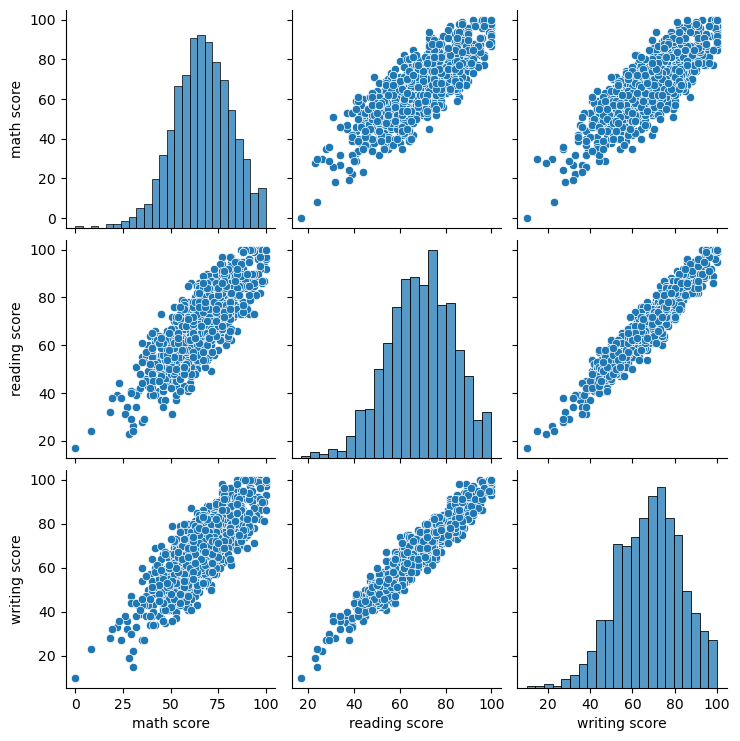

In [18]:
sns.pairplot(df)
plt.show()

# Step 5: Correlation heatmap

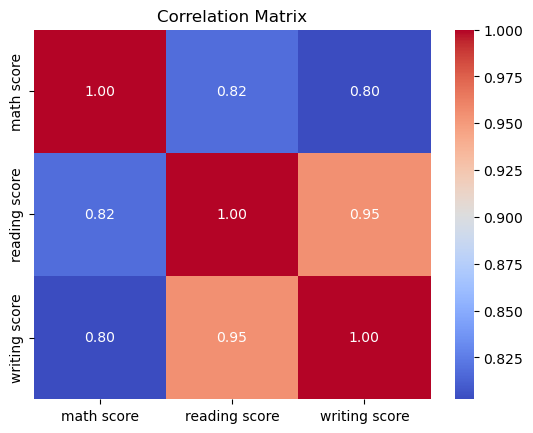

In [20]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure()
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm',fmt=".2f",)
plt.title("Correlation Matrix")
plt.show()

# Step 6: Distribution of numerical features

Text(0.5, 1.0, 'writing score distribution')

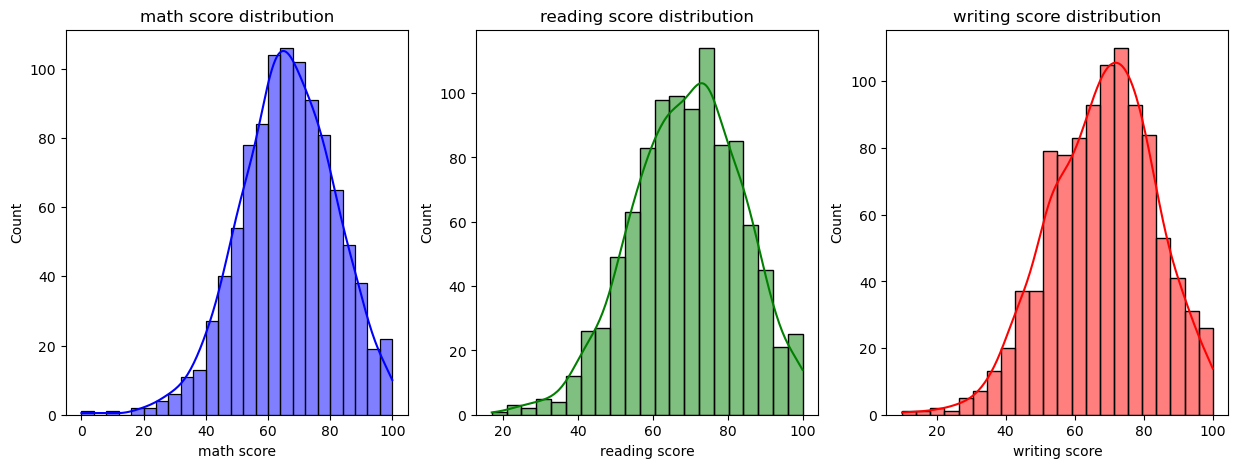

In [28]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['math score'],kde=True,color='blue')
plt.title('math score distribution')

plt.subplot(1,3,2)
sns.histplot(df['reading score'],kde=True,color='green')
plt.title('reading score distribution')

plt.subplot(1,3,3)
sns.histplot(df['writing score'],kde=True,color='red')
plt.title('writing score distribution')

# Step 7: Apply StandardScaler

In [38]:
from sklearn.preprocessing import StandardScaler
X=df[['math score','reading score','writing score']]
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled,columns=X.columns)
print(X_scaled_df.head())

   math score  reading score  writing score
0    0.390024       0.193999       0.391492
1    0.192076       1.427476       1.313269
2    1.577711       1.770109       1.642475
3   -1.259543      -0.833899      -1.583744
4    0.653954       0.605158       0.457333


# Step 8: Elbow method to find optimal k

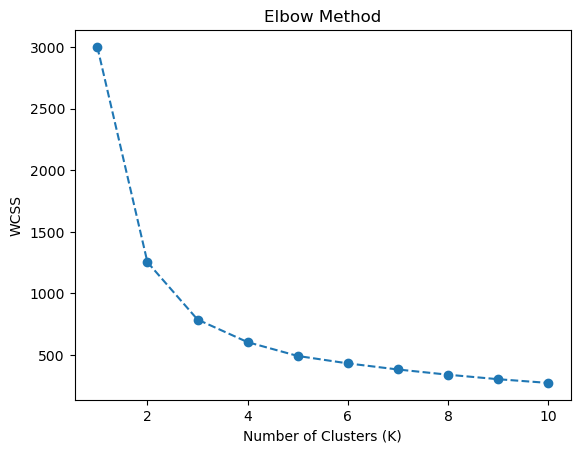

In [60]:
from sklearn.cluster import KMeans
# Calculate WCSS (Within-Cluster Sum of Squares)
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o',linestyle='--')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()


# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [54]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  Cluster  
0                    none          72             72             74        0  
1               completed          69             90             88        2  
2                    none          90             95             93        2  
3                    none          47             57             44        1  
4                    none          76             78             75        2  


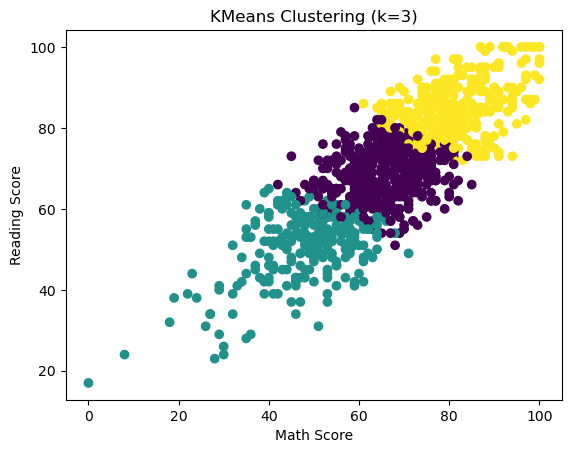

In [56]:
plt.figure()
plt.scatter(df['math score'], df['reading score'], c=df['Cluster'])
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("KMeans Clustering (k=3)")
plt.show()

# Step 10: Print Cluster Center

In [58]:
print("Cluster Centers (Scaled):")
print(kmeans.cluster_centers_)

Cluster Centers (Scaled):
[[-0.04951336 -0.04870596 -0.01529686]
 [-1.18720058 -1.26762535 -1.28838441]
 [ 1.03099793  1.09485536  1.06358515]]


# Step 11: Plot Cluster